# EDA roadmap - foundational questions

One quarter of data, 7,043 customers, ~26.5% churned. `Quarter` is a constant in the
source, so **there is no time dimension**: every question below is cross-sectional.
"Churn over time" can only be approached through `tenure_in_months` as a proxy for
lifecycle stage, never as a trend.

Ground rules for every cut below:
- report the **base rate (26.5%) alongside every segment rate** - a segment is only
  interesting relative to it
- report **n per segment**, and treat anything under ~100 customers as directional only
- distinguish **churn rate** (risk within a segment) from **share of churners**
  (where the volume sits). The age finding already shows these disagree.

---






## 4. Price and perceived value

- Churn rate across `monthly_charge` deciles. Is the relationship monotonic?
- Charge per service held: does a customer paying a lot *for little* churn more than one
  paying a lot for a lot? (Derive a services count from the boolean flags.)
- Do `total_refunds` and `total_extra_data_charges` > 0 mark unhappy customers?
- `total_charges` is mostly tenure x price - check it is not just re-telling section 2.

## 7. Geography

- Churn rate by `city` - top and bottom 10 by rate, with n shown. How much of the spread
  is real and how much is small-sample noise?
- Is there a relationship between zip `population` (density proxy) and churn? Urban
  markets have more competitor choice.
- Do the high-churn cities concentrate in one `churn_category`?

## 8. Acquisition - offers and referrals

- Churn rate by `offer` ('offer a'-'offer e', 'none'). Which offers bought loyalty and
  which bought a customer who left anyway?
- Careful: offers are not randomly assigned. Are they concentrated in particular tenure
  or contract groups?
- Does `referred_a_friend` / `number_of_referrals` predict retention? Referrers are
  usually the most engaged customers.

## 9. Stated reasons - what the churners say

- Breakdown of `churn_category` and the top `churn_reason` values. How much is
  competitor-driven vs price vs service vs attitude?
- Which categories are **addressable**? Competitor offers and price are commercial
  levers; "attitude of support person" is an operational one.
- Does the reason mix differ by segment - do seniors, fiber customers, or month-to-month
  customers leave for different reasons?

## 10. Value at risk

- Churn rate weighted by `cltv` and by `monthly_charge`: which segment holds the most
  *revenue* at risk, as opposed to the most customers?
- Is churn concentrated among low-value customers (cheap to lose) or high-value ones?
- Sanity-check `cltv` first - is it a source-supplied prediction rather than an observed
  value? If so, treat it as a vendor artefact, not ground truth.

## 11. Leakage - what cannot be used to predict

Everything in `stg_telco__status` is recorded with or after the outcome:

- `satisfaction_score` and `churn_score` - confirm they separate churners almost
  perfectly. That near-perfection is the tell that they are unusable as features.
- `churn_reason` / `churn_category` - null unless the customer churned; useful for
  *explaining* churn, never for predicting it.
- `customer_status` - another encoding of the target.
- `total_revenue` is derived from the other charge columns, so it is redundant rather
  than leaky.
- Which columns remain that would be known **before** the customer churned? That set is
  the real feature space.

## 12. Before concluding anything

- Every headline finding: does it hold inside tenure and contract buckets, or does it
  disappear? (The age finding is the first candidate for this test.)
- Is any finding driven by a segment of fewer than ~100 customers?
- Which two or three findings would actually change what the business does - and what
  would the recommended action be?


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels as stats
from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import Table2x2
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import (
    confint_proportions_2indep,
    proportion_confint,
    proportions_ztest,
)

In [2]:
def run_query(query):
    df = client.query(query).to_dataframe()
    return df


def compare(k1, n1, k2, n2, label1="group", label2="reference"):
    p1, p2 = k1 / n1, k2 / n2
    ci1 = proportion_confint(k1, n1, method="wilson")
    ci2 = proportion_confint(k2, n2, method="wilson")
    d_ci = confint_proportions_2indep(k1, n1, k2, n2, compare="diff", method="newcomb")
    t = Table2x2(np.array([[k1, n1 - k1], [k2, n2 - k2]]))
    rr_ci = t.riskratio_confint()

    print(
        f"{label1}:   {p1 * 100:.1f}%  ({ci1[0] * 100:.1f}, {ci1[1] * 100:.1f})   n={n1}"
    )
    print(
        f"{label2}:   {p2 * 100:.1f}%  ({ci2[0] * 100:.1f}, {ci2[1] * 100:.1f})   n={n2}"
    )
    print(
        f"diff:    {(p1 - p2) * 100:.1f}pp ({d_ci[0] * 100:.1f}, {d_ci[1] * 100:.1f})"
    )
    print(f"ratio:   {t.riskratio:.2f}x ({rr_ci[0]:.2f}, {rr_ci[1]:.2f})")


def compare_groups(data, reference=None, floor=100, method="newcomb"):
    """
    data: dict of {label: (churners, customers)}
    reference: label to compare against. Defaults to the lowest-rate group.
    """
    labels = list(data)
    rates = {g: data[g][0] / data[g][1] for g in labels}

    if reference is None:
        reference = min(rates, key=rates.get)

    k0, n0 = data[reference]
    p0 = rates[reference]

    counts = np.array([[data[g][0], data[g][1] - data[g][0]] for g in labels])
    chi2, p_omnibus, dof, _ = chi2_contingency(counts)

    rows, pvals = [], []
    for g in labels:
        k, n = data[g]
        p = rates[g]
        ci = proportion_confint(k, n, method="wilson")
        row = {
            "group": g,
            "n": n,
            "churners": k,
            "rate": round(p * 100, 1),
            "ci_lo": round(ci[0] * 100, 1),
            "ci_hi": round(ci[1] * 100, 1),
            "thin": n < floor,
        }
        if g == reference:
            row.update(
                diff=None, diff_lo=None, diff_hi=None, ratio=None, excess=None, p=None
            )
            pvals.append(np.nan)
        else:
            d_ci = confint_proportions_2indep(
                k, n, k0, n0, compare="diff", method=method
            )
            t = Table2x2(np.array([[k, n - k], [k0, n0 - k0]]))
            _, pv = proportions_ztest(np.array([k, k0]), np.array([n, n0]))
            row.update(
                diff=round((p - p0) * 100, 1),
                diff_lo=round(d_ci[0] * 100, 1),
                diff_hi=round(d_ci[1] * 100, 1),
                ratio=round(t.riskratio, 2),
                excess=round(n * (p - p0)),
                p=pv,
            )
            pvals.append(pv)
        rows.append(row)

    df = pd.DataFrame(rows)
    mask = ~np.isnan(pvals)
    if mask.sum() > 1:
        adj = multipletests(np.array(pvals)[mask], method="holm")[1]
        df.loc[mask, "p_adj"] = adj
    else:
        df["p_adj"] = df["p"]

    print(
        f"reference: {reference}   omnibus chi2={chi2:.1f}, "
        f"dof={dof}, p={p_omnibus:.2e}\n"
    )
    return df.sort_values("rate")

In [3]:
from dotenv import load_dotenv

load_dotenv()

True

In [4]:
import pandas as pd
from google.cloud import bigquery

client = bigquery.Client(project="focus-appliance-507309-h8")

## 1. Baseline - what am I actually measuring?

In [5]:
query = """
SELECT
  CASE
    WHEN se.tenure_in_months <= 3 THEN '0 0-3'
    WHEN se.tenure_in_months <= 12 THEN '1 4-12'
    WHEN se.tenure_in_months <= 24 THEN '2 13-24'
    ELSE '3 25+'
  END AS tenure_band,
  st.customer_status
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
"""

df = run_query(query)
pd.pivot_table(
    df,
    values="tenure_band",
    index="customer_status",
    columns="tenure_band",
    aggfunc="count",
    fill_value=0,
)

tenure_band,0 0-3,1 4-12,2 13-24,3 25+
customer_status,,,,
churned,597,440,294,538
joined,454,0,0,0
stayed,0,695,730,3295


`joined` status only spans a tenure band of 0 - 3 months, and `stayed` starts from month 4. This might be an indication of a onboarding period and might lead to different churn analysis. `churned` status spans all months, hence two seperate analysis will be conducted to on 0-3 months and 4+ months.

In [6]:
# base churn rate
query = """
SELECT
  COUNT(*) AS customers,
  ROUND(COUNTIF(churn_label) / COUNT(*), 3) AS pct_of_churn
FROM
  `dbt_dev.stg_telco__status` st
  JOIN `dbt_dev.stg_telco__services` se USING (customer_id)
WHERE
  se.tenure_in_months > 3
"""

run_query(query)

,customers,pct_of_churn
0,5992,0.212


## 2. Tenure and lifecycle

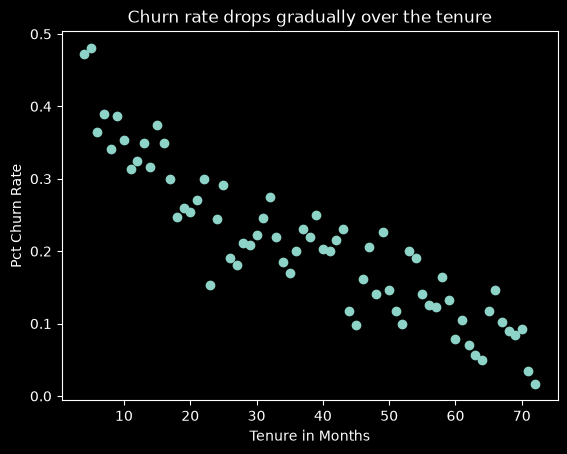

In [7]:
# churn rate by tenure > 3
query = """
SELECT
  se.tenure_in_months,
  COUNTIF(st.churn_label) AS churners,
  COUNT(*) AS customers,
  ROUND(COUNTIF(st.churn_label) * 1.0 / COUNT(*), 3) AS pct_churn
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  se.tenure_in_months
"""

df = run_query(query)
plt.scatter(df["tenure_in_months"], df["pct_churn"])
plt.xlabel("Tenure in Months")
plt.ylabel("Pct Churn Rate")
plt.title("Churn rate drops gradually over the tenure");

Tenure has a negative correlation with churn.

In [8]:
# - What share of *all churners* sits in the first 12 months?

query = """
SELECT
  CASE
    WHEN se.tenure_in_months <= 12 THEN '1 4-12'
    WHEN se.tenure_in_months <= 24 THEN '2 13-24'
    ELSE '3 25+'
  END AS tenure_band,
  COUNT(*) AS churners,
  ROUND(COUNT(*) / SUM(COUNT(*)) OVER (), 3) AS pct_of_churn
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
  AND st.customer_status = 'churned'
GROUP BY
  tenure_band
"""

run_query(query)

,tenure_band,churners,pct_of_churn
0,1 4-12,440,0.346
1,3 25+,538,0.423
2,2 13-24,294,0.231


## 2. Demographics

In [9]:
# which age group churn more?
query = """
SELECT
  IF(age < 65, FALSE, TRUE) AS is_senior,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners,
  ROUND(COUNTIF(st.churn_label) / COUNT(*), 3) AS pct_churn
FROM
  `dbt_dev.stg_telco__demographics` d
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__services` se USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  is_senior
"""

df = run_query(query)
df.rename(index={0: False, 1: True})

,is_senior,customers,churners,pct_churn
False,False,5004,920,0.184
True,True,988,352,0.356


In [10]:
compare(
    df.loc[(df["is_senior"] == True), "churners"].item(),
    df.loc[(df["is_senior"] == True), "customers"].item(),
    df.loc[(df["is_senior"] == False), "churners"].item(),
    df.loc[(df["is_senior"] == False), "customers"].item(),
    "senior",
    "non-senior",
)

senior:   35.6%  (32.7, 38.7)   n=988
non-senior:   18.4%  (17.3, 19.5)   n=5004
diff:    17.2pp (14.1, 20.5)
ratio:   1.94x (1.75, 2.15)


Seniors churn at `35.6%` against `18.4%` — `17.2` ((`95% CI 14.1 to 20.5`))points higher, or `1.93×` the rate (`95% CI 1.74 to 2.14`).

In [11]:
# Age composition of churners

query = """
SELECT
  IF(d.age < 65, FALSE, TRUE) AS is_senior,
  COUNT(*) AS churners,
  SUM(COUNT(*)) OVER () AS total_churners,
  ROUND(COUNT(*) / SUM(COUNT(*)) OVER (), 3) AS pct_of_churn
FROM
  `dbt_dev.stg_telco__demographics` d
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__services` se USING (customer_id)
WHERE
  st.customer_status = 'churned'
  AND se.tenure_in_months > 3
GROUP BY
  is_senior
"""

run_query(query)

,is_senior,churners,total_churners,pct_of_churn
0,False,920,1272,0.723
1,True,352,1272,0.277


In [12]:
query = """
SELECT
  d.married,
  count(*) as customers,
  countif(st.churn_label) as churners,
  round(countif(st.churn_label) / count(*), 3) as pct_of_churn
FROM `dbt_dev.stg_telco__demographics` d
join `dbt_dev.stg_telco__status` st
using(customer_id)
join `dbt_dev.stg_telco__services` se
using(customer_id)
where se.tenure_in_months > 3
group by married
"""

df = run_query(query)
df

,married,customers,churners,pct_of_churn
0,True,3209,560,0.175
1,False,2783,712,0.256


In [13]:
compare(
    df.loc[(df["married"] == False), "churners"].item(),
    df.loc[(df["married"] == False), "customers"].item(),
    df.loc[(df["married"] == True), "churners"].item(),
    df.loc[(df["married"] == True), "customers"].item(),
    "not married",
    "married",
)

not married:   25.6%  (24.0, 27.2)   n=2783
married:   17.5%  (16.2, 18.8)   n=3209
diff:    8.1pp (6.0, 10.2)
ratio:   1.47x (1.33, 1.62)


`not married` customers churn at `25.6%` against `17.5%` - `8.1` (`95% CI 6.0 to 10.2`) points higher, or `1.47×` the rate (`95% CI 1.33 to 1.62`).

In [14]:
query = """
SELECT
  d.number_of_dependents,
  COUNT(*) AS customer,
  COUNTIF(st.churn_label) AS churners,
  ROUND(COUNTIF(st.churn_label) / COUNT(*), 3) AS pct_of_churn
FROM
  `dbt_dev.stg_telco__demographics` d
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__services` se USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  d.number_of_dependents
"""

run_query(query)

,number_of_dependents,customer,churners,pct_of_churn
0,0,4484,1205,0.269
1,1,517,29,0.056
2,2,491,18,0.037
3,3,478,17,0.036
4,4,8,1,0.125
5,5,8,1,0.125
6,6,3,1,0.333
7,7,1,0,0.000
8,8,1,0,0.000
9,9,1,0,0.000


0 dependents churned at a rate of `26.9%`, which is not significantly higher than the overall churn rate of `26.5%`. however, churn rates among customer with dependents seem to be significantly lower, ranging from `5.6%` to `3.6%`. (Dependents count from 4 above is too small to be significant.) This suggests that having dependents may be a factor in churn, but further analysis is needed to determine if this effect persists when controlling for other variables such as contract type and monthly charge.

In [15]:
query = """
SELECT
  IF(
    d.number_of_dependents = 0,
    'zero-dependents',
    '1-3_dependents'
  ) AS dependents,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners,
  ROUND(COUNTIF(st.churn_label) / COUNT(*), 3) AS pct_of_churn
FROM
  `focus-appliance-507309-h8.dbt_dev.stg_telco__demographics` d
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__services` se USING (customer_id)
WHERE
  se.tenure_in_months > 3
  AND d.number_of_dependents < 4
GROUP BY
  dependents
"""

df = run_query(query)

In [16]:
compare(
    df.loc[(df["dependents"] == "zero-dependents"), "churners"].item(),
    df.loc[(df["dependents"] == "zero-dependents"), "customers"].item(),
    df.loc[(df["dependents"] == "1-3_dependents"), "churners"].item(),
    df.loc[(df["dependents"] == "1-3_dependents"), "customers"].item(),
    "zero-dependents",
    "1-3_dependents",
)

zero-dependents:   26.9%  (25.6, 28.2)   n=4484
1-3_dependents:   4.3%  (3.4, 5.5)   n=1486
diff:    22.6pp (20.8, 24.2)
ratio:   6.24x (4.89, 7.97)


Zero Dependents churn at `26.9%` against `4.3%` - `22.6` (`95% CI 20.8 to 24.2`) points higher, or `6.24x` the rate (`95% CI 4.89 to 7.97`).

In [17]:
query = """
SELECT
  d.gender,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners,
  ROUND(COUNTIF(st.churn_label) / COUNT(*), 3) AS pct_of_churn
FROM
  `focus-appliance-507309-h8.dbt_dev.stg_telco__demographics` d
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
  JOIN `dbt_dev.stg_telco__services` se USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  d.gender
"""

df = run_query(query)

In [18]:
compare(
    df.loc[(df["gender"] == "male"), "churners"].item(),
    df.loc[(df["gender"] == "male"), "customers"].item(),
    df.loc[(df["gender"] == "female"), "churners"].item(),
    df.loc[(df["gender"] == "female"), "customers"].item(),
    "male",
    "female",
)

male:   21.1%  (19.7, 22.6)   n=3019
female:   21.4%  (19.9, 22.9)   n=2973
diff:    -0.3pp (-2.3, 1.8)
ratio:   0.99x (0.90, 1.09)


both genders have a churn rate of around `21.3%`. and a non signicicant difference (`-0.3pp  ± 2pp`) between them. This suggests that gender may not be a significant factor in churn, but further analysis is needed to confirm this finding and determine if it persists when controlling for other variables such as contract type and monthly charge.

## 5. Service mix
- Do the streaming flags and `unlimited_data` matter once internet type is held constant?
- Phone-only and internet-only customers: how do they compare to bundled ones?


In [19]:
# What is the churn rate within each internet type

query = """
SELECT
  se.internet_type,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners,
  ROUND(COUNTIF(st.churn_label) / COUNT(*), 3) AS pct_churn
FROM
  `dbt_dev.stg_telco__services` se
  JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  se.internet_type
"""

df = run_query(query)
df

,internet_type,customers,churners,pct_churn
0,none,1274,43,0.034
1,dsl,1411,181,0.128
2,cable,694,133,0.192
3,fiber optic,2613,915,0.350


In [20]:
compare(
    df.loc[(df["internet_type"] == "dsl"), "churners"].item(),
    df.loc[(df["internet_type"] == "dsl"), "customers"].item(),
    df.loc[(df["internet_type"] == "fiber optic"), "churners"].item(),
    df.loc[(df["internet_type"] == "fiber optic"), "customers"].item(),
    "dsl",
    "fiber optic",
)

dsl:   12.8%  (11.2, 14.7)   n=1411
fiber optic:   35.0%  (33.2, 36.9)   n=2613
diff:    -22.2pp (-24.7, -19.6)
ratio:   0.37x (0.32, 0.42)


In [21]:
compare_groups(
    {
        "dsl": (
            df.loc[(df["internet_type"] == "dsl"), "churners"].item(),
            df.loc[(df["internet_type"] == "dsl"), "customers"].item(),
        ),
        "cable": (
            df.loc[(df["internet_type"] == "cable"), "churners"].item(),
            df.loc[(df["internet_type"] == "cable"), "customers"].item(),
        ),
        "fiber optic": (
            df.loc[(df["internet_type"] == "fiber optic"), "churners"].item(),
            df.loc[(df["internet_type"] == "fiber optic"), "customers"].item(),
        ),
    },
    reference="dsl",
)


reference: dsl   omnibus chi2=254.2, dof=2, p=6.29e-56



,group,n,churners,rate,ci_lo,ci_hi,thin,diff,diff_lo,diff_hi,ratio,excess,p,p_adj
0,dsl,1411,181,12.8,11.2,14.7,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,cable,694,133,19.2,16.4,22.3,False,6.3,3.0,9.8,1.49,44.0,1.249359e-04,1.249359e-04
2,fiber optic,2613,915,35.0,33.2,36.9,False,22.2,19.6,24.7,2.73,580.0,1.956732e-51,3.913464e-51


Fiber Optic customers have a `35%` churn rate against a `12.8%` churn rate for DSL customers, a significant `22.2` percentage point difference.  while cable customers have a `19.2%` churn rate, which is `7.3` percentage points lower than fiber optic customers, but still `6.4` percentage points higher than DSL customers. This suggests that internet type may be a significant factor in churn, with fiber optic customers being the most likely to churn, followed by cable customers, and DSL customers being the least likely to churn. Further analysis is needed to determine if this effect persists when controlling for other variables such as contract type and monthly charge.

In [22]:
# whats is the churn rate of individuals with add-ons

query = """
SELECT
  addon_count,
  COUNT(*) AS customers,
  COUNTIF(churn_label) AS churners,
  ROUND(COUNTIF(churn_label) / COUNT(churn_label), 3) AS pct_of_churn
FROM
  (
    SELECT
      *,
      CAST(online_security AS INT64) + CAST(online_backup AS INT64) + CAST(device_protection_plan AS INT64) + CAST(premium_tech_support AS INT64) AS addon_count
    FROM
      `dbt_dev.stg_telco__services` se
      JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
    WHERE
      se.internet_service = TRUE
      AND se.tenure_in_months > 3
  )
GROUP BY
  addon_count
ORDER BY
  addon_count
"""

df = run_query(query)
df


,addon_count,customers,churners,pct_of_churn
0,0,773,361,0.467
1,1,1241,441,0.355
2,2,1303,289,0.222
3,3,931,113,0.121
4,4,470,25,0.053


`add-on` services (online security, online backup, device protection plan, premium tech support) are associated with lower churn rates. Customers with more add-ons tend to be stickier, suggesting that bundling services may improve retention.

In [23]:
query = """
SELECT
  streaming_count,
  COUNT(*) AS customers,
  COUNTIF(churn_label) AS churners,
  ROUND(COUNTIF(churn_label) / COUNT(churn_label), 3) AS pct_of_churn
FROM
  (
    SELECT
      *,
      CAST(streaming_movies AS INT64) + CAST(streaming_tv AS INT64) + CAST(streaming_music AS INT64) AS streaming_count
    FROM
      `dbt_dev.stg_telco__services` se
      JOIN `dbt_dev.stg_telco__status` st USING (customer_id)
    WHERE
      internet_service = TRUE
      AND se.tenure_in_months > 3
  )
GROUP BY
  streaming_count
ORDER BY
  streaming_count
"""

run_query(query)

,streaming_count,customers,churners,pct_of_churn
0,0,1428,334,0.234
1,1,811,241,0.297
2,2,886,258,0.291
3,3,1593,396,0.249


customers who don't use any streaming service have a churn rate of `23.4%`, while those who use one or two have a churn rate of around `29.7%`. With customers who use 3 services having a churn rate of `24.9%`.

## 3. Contract, billing and payment

- Churn rate by `contract` ('month-to-month', 'one year', 'two year'). This is usually
  the single strongest lever - how large is the gap here?
- Churn rate by `payment_method` and by `paperless_billing`. Are these real effects, or
  just proxies for contract type?
- What share of the customer base is month-to-month, and what share of total
  `monthly_charge` does that represent? (Sizes the exposure.)


In [24]:
query = """
SELECT
    se.contract,
    COUNT(*) AS customers,
    COUNTIF(st.churn_label) AS churners,
    ROUND(COUNTIF(st.churn_label) / COUNT(*), 3) AS pct_churn
FROM
    `focus-appliance-507309-h8.dbt_dev.stg_telco__services` se
    JOIN `focus-appliance-507309-h8.dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
    se.tenure_in_months > 3
GROUP BY
    se.contract
"""

df = run_query(query)
df

,contract,customers,churners,pct_churn
0,one year,1524,164,0.108
1,two year,1861,48,0.026
2,month-to-month,2607,1060,0.407


In [26]:
compare_groups(
    {
        "month-to-month": (
            df.loc[(df["contract"] == "month-to-month"), "churners"].item(),
            df.loc[(df["contract"] == "month-to-month"), "customers"].item(),
        ),
        "one year": (
            df.loc[(df["contract"] == "one year"), "churners"].item(),
            df.loc[(df["contract"] == "one year"), "customers"].item(),
        ),
        "two year": (
            df.loc[(df["contract"] == "two year"), "churners"].item(),
            df.loc[(df["contract"] == "two year"), "customers"].item(),
        ),
    },
    reference="month-to-month",
)


reference: month-to-month   omnibus chi2=1075.6, dof=2, p=2.77e-234



,group,n,churners,rate,ci_lo,ci_hi,thin,diff,diff_lo,diff_hi,ratio,excess,p,p_adj
2,two year,1861,48,2.6,2.0,3.4,False,-38.1,-40.1,-36.0,0.06,-709.0,1.224719e-185,2.449439e-185
1,one year,1524,164,10.8,9.3,12.4,False,-29.9,-32.3,-27.4,0.26,-456.0,1.133770e-91,1.133770e-91
0,month-to-month,2607,1060,40.7,38.8,42.6,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN


customer on month-to-month contracts have a churn rate of `40.7%` against `9.3%` for one year (`29.9pp diff, 3.8x more `) and `2.6%` for a two year contract (`38.1pp diff, 16.6x more`).

In [27]:
query = """
select
  se.payment_method,
  count(*) as customers,
  countif(st.churn_label) as churners,
  round(countif(st.churn_label) / count(*), 3) as pct_churn
from `focus-appliance-507309-h8.dbt_dev.stg_telco__services` se
join `focus-appliance-507309-h8.dbt_dev.stg_telco__status` st
using(customer_id)
where se.tenure_in_months > 3
group by se.payment_method
"""

df = run_query(query)
df


,payment_method,customers,churners,pct_churn
0,credit card,2391,271,0.113
1,mailed check,261,60,0.230
2,bank withdrawal,3340,941,0.282


In [34]:
query = """
SELECT
  IF(
    se.payment_method = 'credit card',
    'card',
    'non-card'
  ) AS pay,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners,
  ROUND(COUNTIF(st.churn_label) / COUNT(*), 3) AS pct_churn
FROM
  `focus-appliance-507309-h8.dbt_dev.stg_telco__services` se
  JOIN `focus-appliance-507309-h8.dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  pay
"""

df = run_query(query)
df

,pay,customers,churners,pct_churn
0,card,2391,271,0.113
1,non-card,3601,1001,0.278


In [35]:
compare(
    df.loc[(df["pay"] == "card"), "churners"].item(),
    df.loc[(df["pay"] == "card"), "customers"].item(),
    df.loc[(df["pay"] == "non-card"), "churners"].item(),
    df.loc[(df["pay"] == "non-card"), "customers"].item(),
    "card",
    "non-card",
)


card:   11.3%  (10.1, 12.7)   n=2391
non-card:   27.8%  (26.4, 29.3)   n=3601
diff:    -16.5pp (-18.4, -14.5)
ratio:   0.41x (0.36, 0.46)


customer who do not pay with credit cards have a churn of `27.8%` as against `11.3%` (`16.5pp diff, 2.4x`)

In [ ]:
# CREDIT CARD EFFECT CONTOLLING FOR CONTRACT TYPE


In [33]:
query = """
SELECT
  se.paperless_billing,
  COUNT(*) AS customers,
  COUNTIF(st.churn_label) AS churners,
  ROUND(COUNTIF(st.churn_label) / COUNT(*), 3) AS pct_churn
FROM
  `focus-appliance-507309-h8.dbt_dev.stg_telco__services` se
  JOIN `focus-appliance-507309-h8.dbt_dev.stg_telco__status` st USING (customer_id)
WHERE
  se.tenure_in_months > 3
GROUP BY
  se.paperless_billing
"""

df = run_query(query)
df


,paperless_billing,customers,churners,pct_churn
0,False,2430,284,0.117
1,True,3562,988,0.277
